# EPIC cell fractions and mRNA proportions

**EPIC 细胞比例与 mRNA 比例**

Run EPIC with the packaged TRef reference, inspect both output scales, and retain fit diagnostics.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
tpm = tpm_input()
input_shape = tpm.shape
display(tpm.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
MT-CO1,25097.553024,24055.972843,59199.134752,50164.981725
MT-ND4,14525.308129,14963.923341,48195.670862,32185.130734
MT-CO3,12465.198276,14835.808744,47590.766557,34559.374807
IGKC,9897.134453,78664.047321,713.537221,4372.862276
MT-CO2,12920.617435,13063.071078,33664.670548,21527.455301


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.epic(tpm)
elapsed = perf_counter() - started
display(save_result(result, "08_epic", elapsed, input_shape))

Completed in 0.323 s; input 48,058 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,08_epic,0.323315,"[48058, 10]","{'mRNAProportions': [10, 8], 'cellFractions': ...",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

{'mRNAProportions': (10, 8), 'cellFractions': (10, 8), 'fit_gof': (10, 12)}

## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

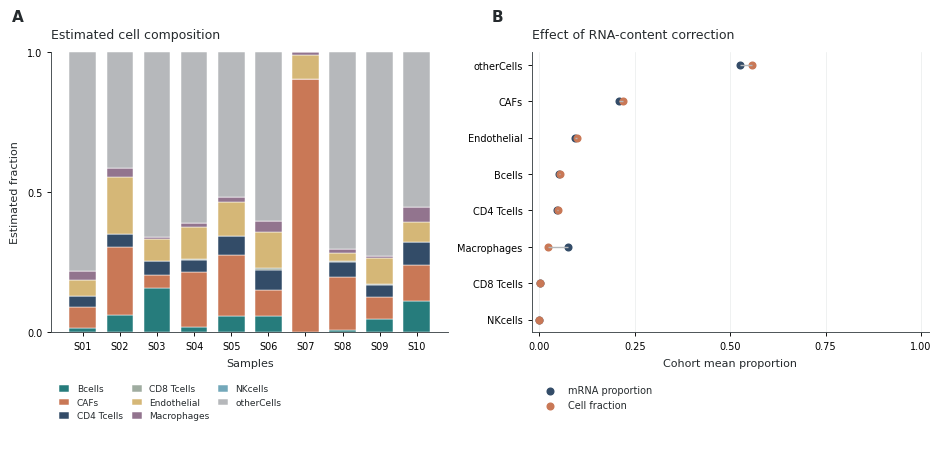

,convergeCode,convergeMessage,RMSE_weighted,Root_mean_squared_geneExpr_weighted,spearmanR
TCGA-BR-6455,0,nnls,83.427891,171.983385,0.709428
TCGA-BR-7196,0,nnls,156.214093,447.562641,0.745500
TCGA-BR-8371,0,nnls,121.544150,159.488116,0.659035
TCGA-BR-8380,0,nnls,158.147097,387.610326,0.737888
TCGA-BR-8592,0,nnls,176.164498,429.655560,0.725711
TCGA-BR-8686,0,nnls,111.997529,214.611529,0.615006
TCGA-BR-A4IV,0,nnls,704.770617,1791.846258,0.853195
TCGA-BR-A4J4,0,nnls,130.666345,360.551477,0.702822
TCGA-BR-A4J9,0,nnls,196.147013,244.657764,0.694407
TCGA-FP-7916,0,nnls,130.271238,273.120710,0.601298


In [5]:
cells, mrna = result["cellFractions"], result["mRNAProportions"]
fig, axes, legends = composition_figure(figsize=(9.3, 4.4), ratios=(1, 1))
stacked(axes[0], cells, max_types=12, legend_ax=legends[0])
order = cells.mean().sort_values().index
y = np.arange(len(order))
axes[1].hlines(y, mrna[order].mean(), cells[order].mean(), color="#B6B8BB", linewidth=1)
axes[1].scatter(mrna[order].mean(), y, s=23, color=NAVY, label="mRNA proportion")
axes[1].scatter(cells[order].mean(), y, s=23, color=RUST, label="Cell fraction")
axes[1].set_yticks(y, clean_labels(order))
axes[1].set(xlabel="Cohort mean proportion", xlim=(-0.02, 1.02))
axes[1].set_xticks([0, 0.25, 0.5, 0.75, 1])
axes[1].grid(axis="x", color="#E9ECEC", linewidth=0.5)
axes[1].set_axisbelow(True)
legends[1].legend(*axes[1].get_legend_handles_labels(), loc="upper left")
panel(axes[0], "A", "Estimated cell composition")
panel(axes[1], "B", "Effect of RNA-content correction")
save_figure(fig, '08_epic')
display(result["fit_gof"].iloc[:, :5])


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

Cell fractions and mRNA proportions differ because of cell-type RNA-content correction. `otherCells` is an uncharacterized remainder; it must not automatically be labeled tumor purity. This example uses a full transcriptome rather than the limited IMvigor210 panel.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/08_epic.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.